# Part A: Location Matching - Entity Resolution

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from rapidfuzz import fuzz

# read the datasets 
raw_financials = pd.read_parquet("raw_financials.parquet")
business_locations = pd.read_parquet("business_locations.parquet")

In [110]:
# first few rows of both the datasets 
print(raw_financials.head())
print(raw_financials.columns)
print(raw_financials.shape)

print(business_locations.head())
print(business_locations.columns)
print(business_locations.shape)

                                     id           name             address  \
0  18a7003e-353e-4170-bcbe-043a17a81fce  Marco'S Pizza  3615 michael grove   
1  17c5c7c4-e962-46db-8e3e-476ee68f150b  Marco'S Pizza  3615 michael grove   
2  200a135b-8003-4144-90fe-4a756fa5484d  Marco'S Pizza  3615 michael grove   
3  7a13f4d4-7c67-4a59-89c3-be1090dca3e2  Marco'S Pizza  3615 michael grove   
4  415d4ba7-93e9-421c-b5e4-ab07a6ee1729  Marco'S Pizza  3615 michael grove   

         city state postal_code    start_at     end_at    revenue  
0  LOUISVILLE    CO       69649  2022-02-01 2022-02-28  125464.83  
1  LOUISVILLE    CO       69649  2022-03-01 2022-03-31  121789.11  
2  LOUISVILLE    CO       69649  2022-04-01 2022-04-30  119231.81  
3  LOUISVILLE    CO       69649  2022-05-01 2022-05-31  118129.99  
4  LOUISVILLE    CO       69649  2022-07-01 2022-07-31  112274.57  
Index(['id', 'name', 'address', 'city', 'state', 'postal_code', 'start_at',
       'end_at', 'revenue'],
      dtype='objec

In [111]:
# Keep only location-level columns in the financial dataset
financial_locations = raw_financials[
    ["name", "address", "city", "state", "postal_code"]
].drop_duplicates().reset_index(drop=True)

# Add a unique ID for each deduplicated financial location
financial_locations["financial_location_id"] = range(1, len(financial_locations) + 1)

# Reorder columns
financial_locations = financial_locations[
    ["financial_location_id", "name", "address", "city", "state", "postal_code"]
]

# Preview
print(financial_locations.shape)
display(financial_locations.head())

(349278, 6)


,financial_location_id,name,address,city,state,postal_code
0,1,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649
1,2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69640
2,3,Marco'S Pizza,913 sandra ports apt. 149,PLANT CITY,FL,95200
3,4,Marco'S Pizza,913 sandra ports apt. 149,PLANT CITY,FL,95207
4,5,Marco'S Pizza,721 william grove,ANNAPOLIS,MD,75532


### CLEAN RAW_FINANCIALS AND BUSINESS LOCATIONS DATASET

In [112]:
# Helper function to clean text
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip() # lowercase + trim spaces
    x = re.sub(r"[^\w\s]", "", x)  # remove punctuation
    x = re.sub(r"\s+", " ", x) # remove extra spaces
    return x


# Helper function to standardize addresses
def clean_address(x):
    x = clean_text(x)

    # standardize common address words
    x = re.sub(r"\bst\b", "street", x)
    x = re.sub(r"\brd\b", "road", x)
    x = re.sub(r"\bave\b", "avenue", x)
    x = re.sub(r"\bblvd\b", "boulevard", x)
    x = re.sub(r"\bdr\b", "drive", x)
    x = re.sub(r"\bln\b", "lane", x)
    x = re.sub(r"\bct\b", "court", x)
    x = re.sub(r"\bapt\b", "apartment", x)
    x = re.sub(r"\bste\b", "suite", x)

    return x


# Clean financial_locations table
financial_locations["name_clean"] = financial_locations["name"].apply(clean_text)
financial_locations["address_clean"] = financial_locations["address"].apply(clean_address)
financial_locations["city_clean"] = financial_locations["city"].apply(clean_text)
financial_locations["state_clean"] = financial_locations["state"].apply(clean_text)
financial_locations["postal_code_clean"] = financial_locations["postal_code"].astype(str).str.strip()

# Clean business_locations table
business_locations["name_clean"] = business_locations["name"].apply(clean_text)
business_locations["address_clean"] = business_locations["street_address"].apply(clean_address)
business_locations["city_clean"] = business_locations["city"].apply(clean_text)
business_locations["state_clean"] = business_locations["state"].apply(clean_text)
business_locations["postal_code_clean"] = business_locations["postal_code"].astype(str).str.strip()

# Preview cleaned tables
display(financial_locations.head())
display(business_locations.head())

,financial_location_id,name,address,city,state,postal_code,name_clean,address_clean,city_clean,state_clean,postal_code_clean
0,1,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,marcos pizza,3615 michael grove,louisville,co,69649
1,2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69640,marcos pizza,3615 michael grove,louisville,co,69640
2,3,Marco'S Pizza,913 sandra ports apt. 149,PLANT CITY,FL,95200,marcos pizza,913 sandra ports apartment 149,plant city,fl,95200
3,4,Marco'S Pizza,913 sandra ports apt. 149,PLANT CITY,FL,95207,marcos pizza,913 sandra ports apartment 149,plant city,fl,95207
4,5,Marco'S Pizza,721 william grove,ANNAPOLIS,MD,75532,marcos pizza,721 william grove,annapolis,md,75532


,id,business_entity_id,name,street_address,city,state,postal_code,area_sq_ft,name_clean,address_clean,city_clean,state_clean,postal_code_clean
0,5274da0a-9746-4e96-92c3-4b6054541f74,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY SANDWICHES,26773 Barrera Expressway,Waterford,CT,50173,1791,subway sandwiches,26773 barrera expressway,waterford,ct,50173
1,44784a1f-481d-4e53-a5a1-767bed1657e3,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY,7468 Moore Hill Apt. 098,Hawthorne,CA,08490,1198,subway,7468 moore hill apartment 098,hawthorne,ca,08490
2,b517801b-49c7-49f2-9813-da5d99a8b087,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY SANDWICHES,09788 Brian Pass Apt. 219,Ceres,CA,09408,5237,subway sandwiches,09788 brian pass apartment 219,ceres,ca,09408
3,1688124d-0d52-49ea-a10b-18946869bb7d,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY SANDWICHES,1939 Christine Manor,Los Altos,CA,86664,1354,subway sandwiches,1939 christine manor,los altos,ca,86664
4,40345c64-4be4-4d75-a2ca-f7c19f7597e0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY,3534 Anderson Rue Suite 751,Great Kills,NY,01721,7028,subway,3534 anderson rue suite 751,great kills,ny,01721


### 1ST PASS MATCHING

In [113]:
# Blocking using state + postal code

# keep only needed columns from business_locations
business_block = business_locations[
    ["id", "business_entity_id", "name", "street_address",
     "name_clean", "address_clean", "city_clean", "state_clean", "postal_code_clean"]
].copy()

# create candidate pairs by blocking on state + postal code
candidate_pairs = financial_locations.merge(
    business_block,
    on=["state_clean", "postal_code_clean"],
    how="inner",
    suffixes=("_fin", "_biz")
)

# preview
print(candidate_pairs.shape)
display(candidate_pairs.head())

(176428, 18)


,financial_location_id,name_fin,address,city,state,postal_code,name_clean_fin,address_clean_fin,city_clean_fin,state_clean,postal_code_clean,id,business_entity_id,name_biz,street_address,name_clean_biz,address_clean_biz,city_clean_biz
0,1,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,marcos pizza,3615 michael grove,louisville,co,69649,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,MARCO'S PIZZA,3615 Michael Grove,marcos pizza,3615 michael grove,louisville
1,3,Marco'S Pizza,913 sandra ports apt. 149,PLANT CITY,FL,95200,marcos pizza,913 sandra ports apartment 149,plant city,fl,95200,78d68f49-aaa2-453c-a963-98301f13ed13,23e2fcb4-72d8-467d-894a-05e430b187ef,MARCO'S PIZZA,913 Sandra Ports Apt. 149,marcos pizza,913 sandra ports apartment 149,plant city
2,5,Marco'S Pizza,721 william grove,ANNAPOLIS,MD,75532,marcos pizza,721 william grove,annapolis,md,75532,a0affaef-17ee-4d7f-beb0-ac97b3527fcd,23e2fcb4-72d8-467d-894a-05e430b187ef,MARCO'S PIZZA,721 William Grove,marcos pizza,721 william grove,annapolis
3,7,Marco'S Pizza,461 moreno tnl.,SAN MATEO,CA,41077,marcos pizza,461 moreno tnl,san mateo,ca,41077,95462442-a653-4706-b2f4-712a6868f203,10f1bc81-448a-4a9e-a6b2-bc5b50c187fc,ARBY'S,39593 Tamara Loaf,arbys,39593 tamara loaf,bellflower
4,7,Marco'S Pizza,461 moreno tnl.,SAN MATEO,CA,41077,marcos pizza,461 moreno tnl,san mateo,ca,41077,d307d1e0-8f30-49b7-bce9-cf14589c1902,23e2fcb4-72d8-467d-894a-05e430b187ef,MARCO'S PIZZA,461 Moreno Tunnel,marcos pizza,461 moreno tunnel,san mateo


In [114]:
# Similarity scores for name and address

# similarity for business/store name
candidate_pairs["name_score"] = candidate_pairs.apply(
    lambda row: fuzz.token_sort_ratio(row["name_clean_fin"], row["name_clean_biz"]),
    axis=1
)

# similarity for address
candidate_pairs["address_score"] = candidate_pairs.apply(
    lambda row: fuzz.token_sort_ratio(row["address_clean_fin"], row["address_clean_biz"]),
    axis=1
)

# exact-match helpers
candidate_pairs["city_match"] = (
    candidate_pairs["city_clean_fin"] == candidate_pairs["city_clean_biz"]
).astype(int)

candidate_pairs["postal_match"] = (
    candidate_pairs["postal_code_clean"] == candidate_pairs["postal_code_clean"]
).astype(int)

# preview
candidate_pairs[
    ["financial_location_id", "id", "name_clean_fin", "name_clean_biz",
     "address_clean_fin", "address_clean_biz", "name_score", "address_score", "city_match"]
].head()

,financial_location_id,id,name_clean_fin,name_clean_biz,address_clean_fin,address_clean_biz,name_score,address_score,city_match
0,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,marcos pizza,marcos pizza,3615 michael grove,3615 michael grove,100.000000,100.000000,1
1,3,78d68f49-aaa2-453c-a963-98301f13ed13,marcos pizza,marcos pizza,913 sandra ports apartment 149,913 sandra ports apartment 149,100.000000,100.000000,1
2,5,a0affaef-17ee-4d7f-beb0-ac97b3527fcd,marcos pizza,marcos pizza,721 william grove,721 william grove,100.000000,100.000000,1
3,7,95462442-a653-4706-b2f4-712a6868f203,marcos pizza,arbys,461 moreno tnl,39593 tamara loaf,35.294118,25.806452,0
4,7,d307d1e0-8f30-49b7-bce9-cf14589c1902,marcos pizza,marcos pizza,461 moreno tnl,461 moreno tunnel,100.000000,90.322581,1


In [115]:
# Final match score + keep best match

# create one overall score
candidate_pairs["final_score"] = (
    0.4 * candidate_pairs["name_score"] +
    0.5 * candidate_pairs["address_score"] +
    0.1 * candidate_pairs["city_match"] * 100
)

# sort so best match comes first for each financial location
candidate_pairs = candidate_pairs.sort_values(
    ["financial_location_id", "final_score"],
    ascending=[True, False]
)

# keep only the best match for each financial location
best_matches = candidate_pairs.drop_duplicates(
    subset=["financial_location_id"],
    keep="first"
).copy()

# preview
print(best_matches.shape)
display(
    best_matches[
        ["financial_location_id", "id", "name_clean_fin", "name_clean_biz",
         "address_clean_fin", "address_clean_biz", "name_score",
         "address_score", "city_match", "final_score"]
    ].head()
)

(163527, 23)


,financial_location_id,id,name_clean_fin,name_clean_biz,address_clean_fin,address_clean_biz,name_score,address_score,city_match,final_score
0,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,marcos pizza,marcos pizza,3615 michael grove,3615 michael grove,100.0,100.000000,1,100.00000
1,3,78d68f49-aaa2-453c-a963-98301f13ed13,marcos pizza,marcos pizza,913 sandra ports apartment 149,913 sandra ports apartment 149,100.0,100.000000,1,100.00000
2,5,a0affaef-17ee-4d7f-beb0-ac97b3527fcd,marcos pizza,marcos pizza,721 william grove,721 william grove,100.0,100.000000,1,100.00000
4,7,d307d1e0-8f30-49b7-bce9-cf14589c1902,marcos pizza,marcos pizza,461 moreno tnl,461 moreno tunnel,100.0,90.322581,1,95.16129
5,10,76b8690f-75f0-4124-9531-65721fdeb8dd,marcos pizza,marcos pizza,707 nelson groves suite 640,707 nelson groves suite 640,100.0,100.000000,1,100.00000


In [116]:
# Keep only confident matches

match_threshold = 85

confirmed_matches = best_matches[
    best_matches["final_score"] >= match_threshold
].copy()

print(confirmed_matches.shape)
display(
    confirmed_matches[
        ["financial_location_id", "id", "name_clean_fin", "name_clean_biz",
         "address_clean_fin", "address_clean_biz", "final_score"]
    ].head()
)

(148700, 23)


,financial_location_id,id,name_clean_fin,name_clean_biz,address_clean_fin,address_clean_biz,final_score
0,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,marcos pizza,marcos pizza,3615 michael grove,3615 michael grove,100.00000
1,3,78d68f49-aaa2-453c-a963-98301f13ed13,marcos pizza,marcos pizza,913 sandra ports apartment 149,913 sandra ports apartment 149,100.00000
2,5,a0affaef-17ee-4d7f-beb0-ac97b3527fcd,marcos pizza,marcos pizza,721 william grove,721 william grove,100.00000
4,7,d307d1e0-8f30-49b7-bce9-cf14589c1902,marcos pizza,marcos pizza,461 moreno tnl,461 moreno tunnel,95.16129
5,10,76b8690f-75f0-4124-9531-65721fdeb8dd,marcos pizza,marcos pizza,707 nelson groves suite 640,707 nelson groves suite 640,100.00000


In [117]:
# Attach matched business location ID back to raw_financials

# 1. Add financial_location_id to every row in raw_financials
raw_financials_with_loc = raw_financials.merge(
    financial_locations[
        ["financial_location_id", "name", "address", "city", "state", "postal_code"]
    ],
    on=["name", "address", "city", "state", "postal_code"],
    how="left"
)

# 2. Keep only the matched IDs from confirmed_matches
matched_ids = confirmed_matches[
    ["financial_location_id", "id", "business_entity_id", "final_score"]
].copy()

# rename business location id 
matched_ids = matched_ids.rename(columns={"id": "matched_location_id"})

# 3. Merge matched business location ID into raw_financials
raw_financials_matched = raw_financials_with_loc.merge(
    matched_ids,
    on="financial_location_id",
    how="left"
)

# Preview
print(raw_financials_matched.shape)
display(raw_financials_matched.head())

(4825372, 13)


,id,name,address,city,state,postal_code,start_at,end_at,revenue,financial_location_id,matched_location_id,business_entity_id,final_score
0,18a7003e-353e-4170-bcbe-043a17a81fce,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-02-01,2022-02-28,125464.83,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
1,17c5c7c4-e962-46db-8e3e-476ee68f150b,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-03-01,2022-03-31,121789.11,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
2,200a135b-8003-4144-90fe-4a756fa5484d,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-04-01,2022-04-30,119231.81,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
3,7a13f4d4-7c67-4a59-89c3-be1090dca3e2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-05-01,2022-05-31,118129.99,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
4,415d4ba7-93e9-421c-b5e4-ab07a6ee1729,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-07-01,2022-07-31,112274.57,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0


In [118]:
# how many raw financial rows got a matched location?
raw_financials_matched["matched_location_id"].notna().sum()

# match rate
raw_financials_matched["matched_location_id"].notna().mean()

# preview only matched rows
display(raw_financials_matched[raw_financials_matched["matched_location_id"].notna()].head())

,id,name,address,city,state,postal_code,start_at,end_at,revenue,financial_location_id,matched_location_id,business_entity_id,final_score
0,18a7003e-353e-4170-bcbe-043a17a81fce,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-02-01,2022-02-28,125464.83,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
1,17c5c7c4-e962-46db-8e3e-476ee68f150b,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-03-01,2022-03-31,121789.11,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
2,200a135b-8003-4144-90fe-4a756fa5484d,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-04-01,2022-04-30,119231.81,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
3,7a13f4d4-7c67-4a59-89c3-be1090dca3e2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-05-01,2022-05-31,118129.99,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
4,415d4ba7-93e9-421c-b5e4-ab07a6ee1729,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-07-01,2022-07-31,112274.57,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0


In [119]:
final_matched_table = raw_financials_matched[
    ["id", "name", "address", "city", "state", "postal_code",
     "start_at", "end_at", "revenue",
     "financial_location_id", "matched_location_id",
     "business_entity_id", "final_score"]
].copy()
print(final_matched_table.shape)

(4825372, 13)


### 1st pass results

In [120]:
# 1. Match summary at unique-location level
total_locations = financial_locations["financial_location_id"].nunique()
matched_locations = confirmed_matches["financial_location_id"].nunique()
unmatched_locations = total_locations - matched_locations
match_rate = matched_locations / total_locations

print("Total unique financial locations :", total_locations)
print("Matched unique locations         :", matched_locations)
print("Unmatched unique locations       :", unmatched_locations)
print("Match rate                       :", round(match_rate * 100, 2), "%")


# 2. Create a table of unmatched locations
unmatched_locations_df = financial_locations[
    ~financial_locations["financial_location_id"].isin(confirmed_matches["financial_location_id"])
].copy()

print("\nUnmatched locations preview:")
display(unmatched_locations_df.head())


# 3. Preview a few confirmed matches
matched_preview = confirmed_matches[
    ["financial_location_id",
     "name_clean_fin", "address_clean_fin", "city_clean_fin", "state_clean", "postal_code_clean",
     "name_clean_biz", "street_address", "city_clean_biz",
     "name_score", "address_score", "final_score"]
].copy()

print("\nSample matched rows:")
display(matched_preview.head())


# 4. Highest-confidence matches
high_conf_matches = confirmed_matches.sort_values("final_score", ascending=False)[
    ["financial_location_id",
     "name_clean_fin", "address_clean_fin",
     "name_clean_biz", "street_address",
     "name_score", "address_score", "final_score"]
]

print("\nHighest-confidence matches:")
display(high_conf_matches.head())


# 5. Lowest-confidence confirmed matches
low_conf_matches = confirmed_matches.sort_values("final_score", ascending=True)[
    ["financial_location_id",
     "name_clean_fin", "address_clean_fin",
     "name_clean_biz", "street_address",
     "name_score", "address_score", "final_score"]
]

print("\nLowest-confidence confirmed matches:")
display(low_conf_matches.head())

Total unique financial locations : 349278
Matched unique locations         : 148700
Unmatched unique locations       : 200578
Match rate                       : 42.57 %

Unmatched locations preview:


,financial_location_id,name,address,city,state,postal_code,name_clean,address_clean,city_clean,state_clean,postal_code_clean
1,2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69640,marcos pizza,3615 michael grove,louisville,co,69640
3,4,Marco'S Pizza,913 sandra ports apt. 149,PLANT CITY,FL,95207,marcos pizza,913 sandra ports apartment 149,plant city,fl,95207
5,6,Marco'S Pizza,721 william grove,ANNAPOLIS,MD,75531,marcos pizza,721 william grove,annapolis,md,75531
7,8,Marco'S Pizza,461 moreno tnl.,SAN MATEO,CA,41079,marcos pizza,461 moreno tnl,san mateo,ca,41079
8,9,Marco'S Pizza,461 moreno tnl.,SAN MATEO,CA,41072,marcos pizza,461 moreno tnl,san mateo,ca,41072



Sample matched rows:


,financial_location_id,name_clean_fin,address_clean_fin,city_clean_fin,state_clean,postal_code_clean,name_clean_biz,street_address,city_clean_biz,name_score,address_score,final_score
0,1,marcos pizza,3615 michael grove,louisville,co,69649,marcos pizza,3615 Michael Grove,louisville,100.0,100.000000,100.00000
1,3,marcos pizza,913 sandra ports apartment 149,plant city,fl,95200,marcos pizza,913 Sandra Ports Apt. 149,plant city,100.0,100.000000,100.00000
2,5,marcos pizza,721 william grove,annapolis,md,75532,marcos pizza,721 William Grove,annapolis,100.0,100.000000,100.00000
4,7,marcos pizza,461 moreno tnl,san mateo,ca,41077,marcos pizza,461 Moreno Tunnel,san mateo,100.0,90.322581,95.16129
5,10,marcos pizza,707 nelson groves suite 640,north liberty,ia,74451,marcos pizza,707 Nelson Groves Suite 640,north liberty,100.0,100.000000,100.00000



Highest-confidence matches:


,financial_location_id,name_clean_fin,address_clean_fin,name_clean_biz,street_address,name_score,address_score,final_score
0,1,marcos pizza,3615 michael grove,marcos pizza,3615 Michael Grove,100.0,100.0,100.0
107768,213780,chipotle mexican grill,45295 meyers bypass apartment 755,chipotle mexican grill,45295 Meyers Bypass Apt. 755,100.0,100.0,100.0
107813,213869,chipotle mexican grill,93787 marshall coves suite 301,chipotle mexican grill,93787 Marshall Coves Suite 301,100.0,100.0,100.0
107812,213864,chipotle mexican grill,24793 kristin stream,chipotle mexican grill,24793 Kristin Stream,100.0,100.0,100.0
107810,213861,chipotle mexican grill,1250 porter wells,chipotle mexican grill,1250 Porter Wells,100.0,100.0,100.0



Lowest-confidence confirmed matches:


,financial_location_id,name_clean_fin,address_clean_fin,name_clean_biz,street_address,name_score,address_score,final_score
140524,278434,laramie ace hardware llc,496 w wy,laramie ace hardware llc,496 West Way,100.0,70.00000,85.000000
6593,13003,office depot tech services,16107 sprks spring,office depot tech services,16107 Sparks Spring,100.0,70.27027,85.135135
38825,76988,kroger,49823 ramirez rdl,kroger,49823 Ramirez Radial,100.0,70.27027,85.135135
56164,111475,five below,98072 charles ctr,five below,98072 Charles Center,100.0,70.27027,85.135135
61151,121371,ross dress for less,16896 jones jcts,ross dress for less,16896 Jones Junctions,100.0,70.27027,85.135135


In [121]:
# one unmatched row
test_row = unmatched_locations_df.iloc[0]
print(test_row[["name", "address", "city", "state", "postal_code"]])

# Check whether any business rows exist with same state + postal code
possible_biz = business_locations[
    (business_locations["state_clean"] == test_row["state_clean"]) &
    (business_locations["postal_code_clean"] == test_row["postal_code_clean"])
]

print("Number of business candidates with same state + postal code:", len(possible_biz))
display(possible_biz.head(10))

name                Marco'S Pizza
address        3615 michael grove
city                   LOUISVILLE
state                          CO
postal_code                 69640
Name: 1, dtype: object
Number of business candidates with same state + postal code: 0


,id,business_entity_id,name,street_address,city,state,postal_code,area_sq_ft,name_clean,address_clean,city_clean,state_clean,postal_code_clean


In [122]:
possible_biz_city = business_locations[
    (business_locations["state_clean"] == test_row["state_clean"]) &
    (business_locations["city_clean"] == test_row["city_clean"])
]

print("Number of business candidates with same state + city:", len(possible_biz_city))
display(possible_biz_city[["name", "street_address", "city", "state", "postal_code"]].head(20))

Number of business candidates with same state + city: 61


,name,street_address,city,state,postal_code
3230,DOLLAR GENERAL STORE,95014 Hurst Point,Louisville,CO,34619
4727,WALGREENS 12406,697 Vanessa Ways Suite 342,Louisville,CO,25187
6963,STARBUCKS,015 Shane Lodge Suite 096,Louisville,CO,04903
9310,CVS PHARMACY,9242 Vincent Trail,Louisville,CO,90294
13300,MCDONALDS,09636 Steven Hollow,Louisville,CO,30227
14370,JACKSON HEWITT TAX SERVICE,265 Velez Parkways Apt. 741,Louisville,CO,54627
14971,JACKSON HEWITT TAX SERVICE,898 Yolanda Ports Apt. 597,Louisville,CO,66904
15014,WALMART,411 Sutton Locks Suite 949,Louisville,CO,77617
17451,CIRCLE K,90289 Kevin Causeway,Louisville,CO,39882
22205,PIZZA HUT EXPRESS,7219 Christopher Turnpike Suite 095,Louisville,CO,49074


This result shows that there are no rows with the name Macro's Pizza & same city and postal code.

This means that every financial row might not be in businesslocation table

In [123]:
unused_business_locations = business_locations[
    ~business_locations["id"].isin(confirmed_matches["id"])
].copy()

print("Unused business rows:", len(unused_business_locations))
display(unused_business_locations.head())

Unused business rows: 171


,id,business_entity_id,name,street_address,city,state,postal_code,area_sq_ft,name_clean,address_clean,city_clean,state_clean,postal_code_clean
293,f16eeb0e-a086-4962-b285-4ef0369bbc82,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY SANDWICHES,513 Walker Well,South Holland,IL,40751,6451,subway sandwiches,513 walker well,south holland,il,40751
853,ac95ffea-f522-4af6-884c-13a2655f2028,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY,209 Woods Ways,Baytown,TX,05404,6391,subway,209 woods ways,baytown,tx,05404
1407,088e2532-1370-424c-a216-078e4515ed7f,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY,4287 Gilmore Gateway,Bloomingdale,IL,68090,8317,subway,4287 gilmore gateway,bloomingdale,il,68090
1435,77b72419-4c08-421f-a1bf-c24c8c1aa444,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY SANDWICHES,12342 Powell Points,West Babylon,NY,07680,3758,subway sandwiches,12342 powell points,west babylon,ny,07680
1549,9f08977a-8a00-41a7-b72a-e4ba84773a7e,bdd640fb-0667-4ad1-9c80-317fa3b1799d,SUBWAY SANDWICHES,89348 Patel Parkway,Coon Rapids,MN,30379,3691,subway sandwiches,89348 patel parkway,coon rapids,mn,30379


### UNUSED BUSINESS LOCATIONS & FINANCIAL ROWS

In [124]:
# Unmatched financial locations from first pass
unmatched_financial_locations = financial_locations[
    ~financial_locations["financial_location_id"].isin(confirmed_matches["financial_location_id"])
].copy()

# Unused business locations from first pass
unused_business_locations = business_locations[
    ~business_locations["id"].isin(confirmed_matches["id"])
].copy()

print("Unmatched financial locations:", unmatched_financial_locations.shape)
print("Unused business locations:", unused_business_locations.shape)

Unmatched financial locations: (200578, 11)
Unused business locations: (171, 13)


### 2nd PASS MATCHING 

In [125]:
# SECOND PASS MATCHING 
# - same state
# - same city
# - similar name
# - similar address
# - ZIP can differ
# - one financial location, one business location


# 1. Extract house number from cleaned address
def extract_house_number(addr):
    if pd.isna(addr):
        return ""
    m = re.match(r"^\s*(\d+)", str(addr))
    return m.group(1) if m else ""

# add house number columns 
financial_locations["house_number"] = financial_locations["address_clean"].apply(extract_house_number)
business_locations["house_number"] = business_locations["address_clean"].apply(extract_house_number)

# 2. Unmatched financial locations from first pass
unmatched_financial_locations = financial_locations[
    ~financial_locations["financial_location_id"].isin(confirmed_matches["financial_location_id"])
].copy()

# 3. Unused business locations from first pass
unused_business_locations = business_locations[
    ~business_locations["id"].isin(confirmed_matches["id"])
].copy()

print("Unmatched financial locations:", unmatched_financial_locations.shape)
print("Unused business locations:", unused_business_locations.shape)

# 4. Candidate generation: same state + same city
candidate_pairs_pass2 = unmatched_financial_locations.merge(
    unused_business_locations[
        [
            "id", "business_entity_id", "name", "street_address",
            "name_clean", "address_clean", "city_clean", "state_clean",
            "postal_code_clean", "house_number"
        ]
    ],
    on=["state_clean", "city_clean"],
    how="inner",
    suffixes=("_fin", "_biz")
)

print("Second-pass candidate pairs:", candidate_pairs_pass2.shape)

# 5. Similarity scores
candidate_pairs_pass2["name_score"] = candidate_pairs_pass2.apply(
    lambda row: fuzz.token_sort_ratio(row["name_clean_fin"], row["name_clean_biz"]),
    axis=1
)

candidate_pairs_pass2["address_score"] = candidate_pairs_pass2.apply(
    lambda row: fuzz.token_set_ratio(row["address_clean_fin"], row["address_clean_biz"]),
    axis=1
)

candidate_pairs_pass2["house_number_match"] = (
    candidate_pairs_pass2["house_number_fin"] == candidate_pairs_pass2["house_number_biz"]
).astype(int)

# ZIP is only a bonus, not a requirement
candidate_pairs_pass2["zip_match"] = (
    candidate_pairs_pass2["postal_code_clean_fin"] == candidate_pairs_pass2["postal_code_clean_biz"]
).astype(int)

# 6. Final score
candidate_pairs_pass2["final_score"] = (
    0.35 * candidate_pairs_pass2["name_score"] +
    0.40 * candidate_pairs_pass2["address_score"] +
    0.20 * candidate_pairs_pass2["house_number_match"] * 100 +
    0.05 * candidate_pairs_pass2["zip_match"] * 100
)

# 7. Keep only strong candidates
filtered_pass2 = candidate_pairs_pass2[
    (candidate_pairs_pass2["name_score"] >= 85) &
    (candidate_pairs_pass2["address_score"] >= 75) &
    (candidate_pairs_pass2["house_number_match"] == 1)
].copy()

print("Filtered second-pass candidates:", filtered_pass2.shape)

# 8. Enforce one-to-one matching
# Sort by highest score first so best pairs are kept
filtered_pass2 = filtered_pass2.sort_values("final_score", ascending=False)

# best business match for each financial location
filtered_pass2 = filtered_pass2.drop_duplicates(
    subset=["financial_location_id"],
    keep="first"
)

# best financial match for each business location
confirmed_matches_pass2 = filtered_pass2.drop_duplicates(
    subset=["id"],
    keep="first"
).copy()

print("Second-pass confirmed matches:", confirmed_matches_pass2.shape)
print("Unique financial ids matched in pass 2:", confirmed_matches_pass2["financial_location_id"].nunique())
print("Unique business ids used in pass 2:", confirmed_matches_pass2["id"].nunique())

# 9. Preview second-pass matches
display(
    confirmed_matches_pass2[
        [
            "financial_location_id", "id", "name_fin", "name_biz",
            "address", "street_address",
            "postal_code_clean_fin", "postal_code_clean_biz",
            "name_score", "address_score",
            "house_number_match", "zip_match", "final_score"
        ]
    ].head(5)
)

Unmatched financial locations: (200578, 12)
Unused business locations: (171, 14)
Second-pass candidate pairs: (12846, 20)
Filtered second-pass candidates: (418, 25)
Second-pass confirmed matches: (165, 25)
Unique financial ids matched in pass 2: 165
Unique business ids used in pass 2: 165


,financial_location_id,id,name_fin,name_biz,address,street_address,postal_code_clean_fin,postal_code_clean_biz,name_score,address_score,house_number_match,zip_match,final_score
3276,89534,d065fc24-e3b8-4114-808a-081a8429c481,Kohl'S,KOHL'S,507 prk.er prairie,507 Parker Prairie,66030,66030,100.0,97.142857,1,1,98.857143
7628,206489,caf00a5d-2c8d-4675-a77d-c6bd5891bc12,SEPHORA,SEPHORA,666 patricia prk.s,666 Patricia Parks,53782,53782,100.0,97.142857,1,1,98.857143
5907,162220,f3c284ab-637b-40a6-b042-50fc3ea84791,ANYTIME FITNESS,ANYTIME FITNESS,9229 Prk.Er Plaza,9229 Parker Plaza,16571,16571,100.0,96.969697,1,1,98.787879
11434,308807,c8fc63b0-562c-4291-af91-d8897ade9dd0,Mcdonald'S,MCDONALD'S,00956 Perry Prk.S,00956 Perry Parks,16325,16325,100.0,96.969697,1,1,98.787879
7015,189989,b6aec419-51d1-4629-8d2b-9bb9c8e01da7,Jersey Mike'S Subs,JERSEY MIKE'S SUBS,4161 patton prk.s,4161 Patton Parks,80877,80877,100.0,96.969697,1,1,98.787879


In [126]:
# Combine first and second pass matches
all_confirmed_matches = pd.concat(
    [confirmed_matches, confirmed_matches_pass2],
    ignore_index=True
)

print("Total confirmed matches after two passes:", all_confirmed_matches.shape)
print("Unique financial locations matched:", all_confirmed_matches["financial_location_id"].nunique())
print("Unique business locations used:", all_confirmed_matches["id"].nunique())

Total confirmed matches after two passes: (148865, 30)
Unique financial locations matched: 148865
Unique business locations used: 148865


In [127]:
total_locations = financial_locations["financial_location_id"].nunique()
matched_locations = all_confirmed_matches["financial_location_id"].nunique()
unmatched_locations = total_locations - matched_locations
match_rate = matched_locations / total_locations

print("Total unique financial locations :", total_locations)
print("Matched unique locations         :", matched_locations)
print("Unmatched unique locations       :", unmatched_locations)
print("Match rate                       :", round(match_rate * 100, 2), "%")

print("Business location rows used      :", all_confirmed_matches["id"].nunique())
print("Unused business location rows    :", business_locations["id"].nunique() - all_confirmed_matches["id"].nunique())

Total unique financial locations : 349278
Matched unique locations         : 148865
Unmatched unique locations       : 200413
Match rate                       : 42.62 %
Business location rows used      : 148865
Unused business location rows    : 6


### Final summary statistics for PART A

In [128]:
all_confirmed_matches = pd.concat(
    [confirmed_matches, confirmed_matches_pass2],
    ignore_index=True
)

# Core counts
total_locations = financial_locations["financial_location_id"].nunique()
first_pass_matches = confirmed_matches["financial_location_id"].nunique()
total_matched_locations = all_confirmed_matches["financial_location_id"].nunique()
second_pass_recovered = total_matched_locations - first_pass_matches
unmatched_locations = total_locations - total_matched_locations

# Percentages 
first_pass_pct = round(first_pass_matches / total_locations * 100, 2)
second_pass_pct = round(second_pass_recovered / total_locations * 100, 2)
unmatched_pct = round(unmatched_locations / total_locations * 100, 2)

# Print summary
print("Total Locations        :", total_locations)
print("First-Pass Matches     :", first_pass_matches)
print("Second-Pass Recovered  :", second_pass_recovered)
print("Unmatched Locations    :", unmatched_locations)

print("\nComposition Percentages")
print("First Pass %           :", first_pass_pct)
print("Second Pass %          :", second_pass_pct)
print("Unmatched %            :", unmatched_pct)

Total Locations        : 349278
First-Pass Matches     : 148700
Second-Pass Recovered  : 165
Unmatched Locations    : 200413

Composition Percentages
First Pass %           : 42.57
Second Pass %          : 0.05
Unmatched %            : 57.38


### Final table after both the pass

In [129]:
# FINAL TABLE AFTER SECOND PASS

# 1. Combine first-pass and second-pass matches
all_confirmed_matches = pd.concat(
    [confirmed_matches, confirmed_matches_pass2],
    ignore_index=True
)

# 2. Keep only the columns needed from the final matched location table
final_match_ids = all_confirmed_matches[
    ["financial_location_id", "id", "business_entity_id", "final_score"]
].copy()

# rename business location id 
final_match_ids = final_match_ids.rename(columns={"id": "matched_location_id"})

# 3. Add financial_location_id back to every row in raw_financials
raw_financials_with_loc = raw_financials.merge(
    financial_locations[
        ["financial_location_id", "name", "address", "city", "state", "postal_code"]
    ],
    on=["name", "address", "city", "state", "postal_code"],
    how="left"
)

# 4. Merge final matched business location info into full financial table
final_matched_table = raw_financials_with_loc.merge(
    final_match_ids,
    on="financial_location_id",
    how="left"
)

# 5. Reorder columns 
final_matched_table = final_matched_table[
    [
        "id",  # raw financial row id
        "name",
        "address",
        "city",
        "state",
        "postal_code",
        "start_at",
        "end_at",
        "revenue",
        "financial_location_id",
        "matched_location_id",   # matched business location id
        "business_entity_id",
        "final_score"
    ]
].copy()

# 6. Preview
print(final_matched_table.shape)
display(final_matched_table.head())

# 7. save to CSV
final_matched_table.to_csv("final_matched_table_after_second_pass.csv", index=False)

(4825372, 13)


,id,name,address,city,state,postal_code,start_at,end_at,revenue,financial_location_id,matched_location_id,business_entity_id,final_score
0,18a7003e-353e-4170-bcbe-043a17a81fce,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-02-01,2022-02-28,125464.83,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
1,17c5c7c4-e962-46db-8e3e-476ee68f150b,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-03-01,2022-03-31,121789.11,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
2,200a135b-8003-4144-90fe-4a756fa5484d,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-04-01,2022-04-30,119231.81,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
3,7a13f4d4-7c67-4a59-89c3-be1090dca3e2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-05-01,2022-05-31,118129.99,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0
4,415d4ba7-93e9-421c-b5e4-ab07a6ee1729,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-07-01,2022-07-31,112274.57,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0


# Part B: Revenue Analysis - Financial Adjustment

In [130]:
# PART B - TASK 1
# Create financial table with: matched location IDs, raw revenue, adjusted revenue placeholder

# 1. Combine first-pass and second-pass matches
all_confirmed_matches = pd.concat(
    [confirmed_matches, confirmed_matches_pass2],
    ignore_index=True
)

# 2. Keep only needed match columns
final_match_ids = all_confirmed_matches[
    ["financial_location_id", "id", "business_entity_id", "final_score"]
].copy()

# rename business location id for clarity
final_match_ids = final_match_ids.rename(columns={"id": "matched_location_id"})

# 3. Attach financial_location_id back to raw_financials
raw_financials_with_loc = raw_financials.merge(
    financial_locations[
        ["financial_location_id", "name", "address", "city", "state", "postal_code"]
    ],
    on=["name", "address", "city", "state", "postal_code"],
    how="left"
)

# 4. Merge matched business location info
financial_table = raw_financials_with_loc.merge(
    final_match_ids,
    on="financial_location_id",
    how="left"
)

# 5. Rename raw revenue clearly
financial_table = financial_table.rename(columns={"revenue": "raw_revenue"})

# 6. Create placeholder adjusted revenue column
financial_table["adjusted_revenue"] = pd.NA

# 7. Keep only the main columns needed for Part B
financial_table = financial_table[
    [
        "id",   # financial record id
        "name",
        "address",
        "city",
        "state",
        "postal_code",
        "start_at",
        "end_at",
        "financial_location_id",
        "matched_location_id",
        "business_entity_id",
        "final_score",
        "raw_revenue",
        "adjusted_revenue"
    ]
].copy()

# 8. Preview
print(financial_table.shape)
display(financial_table.head())

(4825372, 14)


,id,name,address,city,state,postal_code,start_at,end_at,financial_location_id,matched_location_id,business_entity_id,final_score,raw_revenue,adjusted_revenue
0,18a7003e-353e-4170-bcbe-043a17a81fce,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-02-01,2022-02-28,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,125464.83,<NA>
1,17c5c7c4-e962-46db-8e3e-476ee68f150b,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-03-01,2022-03-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,121789.11,<NA>
2,200a135b-8003-4144-90fe-4a756fa5484d,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-04-01,2022-04-30,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,119231.81,<NA>
3,7a13f4d4-7c67-4a59-89c3-be1090dca3e2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-05-01,2022-05-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,118129.99,<NA>
4,415d4ba7-93e9-421c-b5e4-ab07a6ee1729,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-07-01,2022-07-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,112274.57,<NA>


In [131]:
print("Rows with matched location:", financial_table["matched_location_id"].notna().sum())
print("Rows without matched location:", financial_table["matched_location_id"].isna().sum())

Rows with matched location: 4608278
Rows without matched location: 217094


In [132]:
financial_table_matched = financial_table[
    financial_table["matched_location_id"].notna()
].copy()

print(financial_table_matched.shape)
display(financial_table_matched.head())

(4608278, 14)


,id,name,address,city,state,postal_code,start_at,end_at,financial_location_id,matched_location_id,business_entity_id,final_score,raw_revenue,adjusted_revenue
0,18a7003e-353e-4170-bcbe-043a17a81fce,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-02-01,2022-02-28,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,125464.83,<NA>
1,17c5c7c4-e962-46db-8e3e-476ee68f150b,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-03-01,2022-03-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,121789.11,<NA>
2,200a135b-8003-4144-90fe-4a756fa5484d,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-04-01,2022-04-30,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,119231.81,<NA>
3,7a13f4d4-7c67-4a59-89c3-be1090dca3e2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-05-01,2022-05-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,118129.99,<NA>
4,415d4ba7-93e9-421c-b5e4-ab07a6ee1729,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-07-01,2022-07-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,112274.57,<NA>


In [133]:
# merge area_sq_ft into financial_table_matched

# merge area_sq_ft from business_locations
financial_table_matched = financial_table_matched.merge(
    business_locations[["id", "area_sq_ft"]],
    left_on="matched_location_id",
    right_on="id",
    how="left"
)

# drop extra business id column from the merge
financial_table_matched = financial_table_matched.drop(columns=["id_y"]).rename(
    columns={"id_x": "id"}
)

# preview
print(financial_table_matched.shape)
display(financial_table_matched.head())

print("Missing area_sq_ft:", financial_table_matched["area_sq_ft"].isna().sum())

(4608278, 15)


,id,name,address,city,state,postal_code,start_at,end_at,financial_location_id,matched_location_id,business_entity_id,final_score,raw_revenue,adjusted_revenue,area_sq_ft
0,18a7003e-353e-4170-bcbe-043a17a81fce,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-02-01,2022-02-28,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,125464.83,<NA>,9091
1,17c5c7c4-e962-46db-8e3e-476ee68f150b,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-03-01,2022-03-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,121789.11,<NA>,9091
2,200a135b-8003-4144-90fe-4a756fa5484d,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-04-01,2022-04-30,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,119231.81,<NA>,9091
3,7a13f4d4-7c67-4a59-89c3-be1090dca3e2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-05-01,2022-05-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,118129.99,<NA>,9091
4,415d4ba7-93e9-421c-b5e4-ab07a6ee1729,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-07-01,2022-07-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,112274.57,<NA>,9091


Missing area_sq_ft: 0


### 1. By size

In [134]:
# create size buckets from area_sq_ft

def assign_size_bucket(x):
    if pd.isna(x):
        return "unknown"
    elif x < 2000:
        return "small"
    elif x < 5000:
        return "medium"
    else:
        return "large"

financial_table_matched["size_bucket"] = financial_table_matched["area_sq_ft"].apply(assign_size_bucket)

# preview
display(
    financial_table_matched[
        ["matched_location_id", "area_sq_ft", "size_bucket"]
    ].head(10)
)

# count stores in each bucket
print(financial_table_matched["size_bucket"].value_counts(dropna=False))

,matched_location_id,area_sq_ft,size_bucket
0,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
2,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
3,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
4,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
5,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
6,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
7,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
8,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large
9,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large


size_bucket
large     2436281
medium    1446393
small      725604
Name: count, dtype: int64


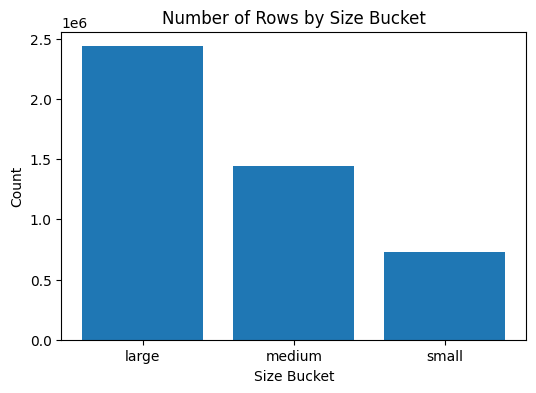

In [135]:
multiplier_counts = financial_table_matched["size_bucket"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(multiplier_counts.index, multiplier_counts.values)
plt.xlabel("Size Bucket")
plt.ylabel("Count")
plt.title("Number of Rows by Size Bucket")
plt.show()

In [136]:
# assign multiplier by size bucket

def assign_multiplier(bucket):
    if bucket == "small":
        return 1.25
    elif bucket == "medium":
        return 1.20
    elif bucket == "large":
        return 1.15
    else:
        return 1.20   # default for unknown

financial_table_matched["revenue_multiplier"] = financial_table_matched["size_bucket"].apply(assign_multiplier)

# preview
display(
    financial_table_matched[
        ["matched_location_id", "area_sq_ft", "size_bucket", "revenue_multiplier"]
    ].head(10)
)

# check distribution
print(financial_table_matched["revenue_multiplier"].value_counts())

,matched_location_id,area_sq_ft,size_bucket,revenue_multiplier
0,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
2,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
3,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
4,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
5,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
6,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
7,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
8,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15
9,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,9091,large,1.15


revenue_multiplier
1.15    2436281
1.20    1446393
1.25     725604
Name: count, dtype: int64


In [137]:
financial_table_matched["adjusted_revenue"] = (
    financial_table_matched["raw_revenue"] * financial_table_matched["revenue_multiplier"]
)

In [138]:
financial_table_matched.head()

,id,name,address,city,state,postal_code,start_at,end_at,financial_location_id,matched_location_id,business_entity_id,final_score,raw_revenue,adjusted_revenue,area_sq_ft,size_bucket,revenue_multiplier
0,18a7003e-353e-4170-bcbe-043a17a81fce,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-02-01,2022-02-28,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,125464.83,144284.5545,9091,large,1.15
1,17c5c7c4-e962-46db-8e3e-476ee68f150b,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-03-01,2022-03-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,121789.11,140057.4765,9091,large,1.15
2,200a135b-8003-4144-90fe-4a756fa5484d,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-04-01,2022-04-30,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,119231.81,137116.5815,9091,large,1.15
3,7a13f4d4-7c67-4a59-89c3-be1090dca3e2,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-05-01,2022-05-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,118129.99,135849.4885,9091,large,1.15
4,415d4ba7-93e9-421c-b5e4-ab07a6ee1729,Marco'S Pizza,3615 michael grove,LOUISVILLE,CO,69649,2022-07-01,2022-07-31,1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,23e2fcb4-72d8-467d-894a-05e430b187ef,100.0,112274.57,129115.7555,9091,large,1.15


In [139]:
financial_table_matched.to_csv("adjusted_revenue_bysize.csv", index=False)

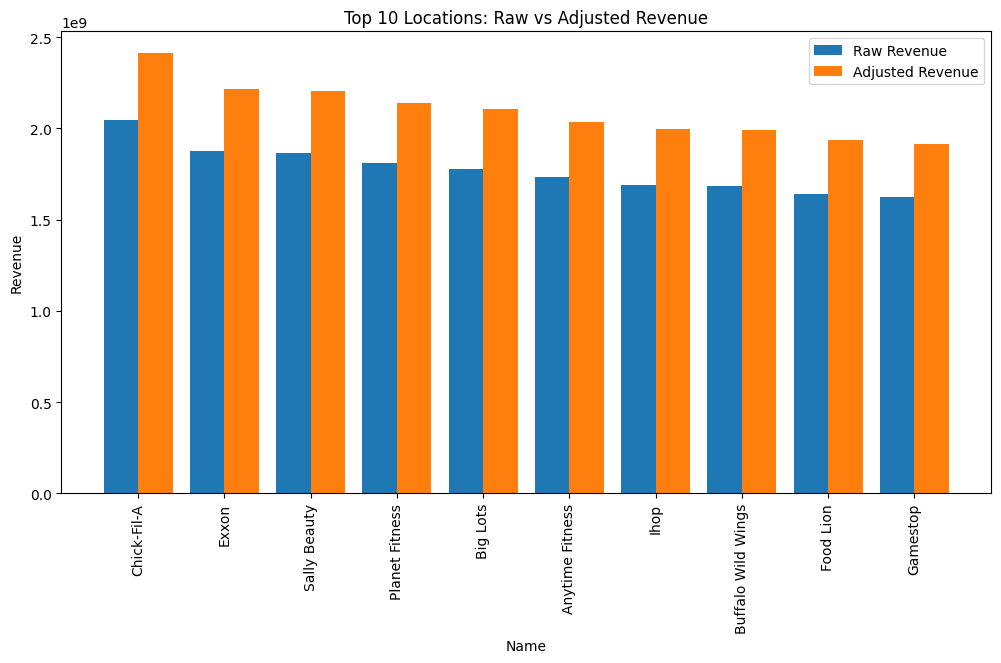

In [140]:
top_locations = (
    financial_table_matched
    .groupby("name", as_index=False)[["raw_revenue", "adjusted_revenue"]]
    .sum()
    .sort_values("adjusted_revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
x = range(len(top_locations))

plt.bar(x, top_locations["raw_revenue"], width=0.4, label="Raw Revenue")
plt.bar([i + 0.4 for i in x], top_locations["adjusted_revenue"], width=0.4, label="Adjusted Revenue")

plt.xticks([i + 0.2 for i in x], top_locations["name"], rotation=90)
plt.xlabel("Name")
plt.ylabel("Revenue")
plt.title("Top 10 Locations: Raw vs Adjusted Revenue")
plt.legend()
plt.show()

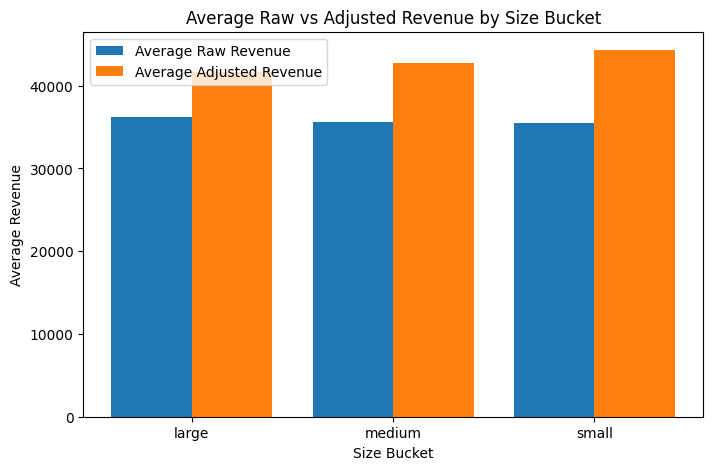

In [141]:
bucket_summary = (
    financial_table_matched
    .groupby("size_bucket", as_index=False)[["raw_revenue", "adjusted_revenue"]]
    .mean()
)

plt.figure(figsize=(8, 5))
x = range(len(bucket_summary))

plt.bar(x, bucket_summary["raw_revenue"], width=0.4, label="Average Raw Revenue")
plt.bar([i + 0.4 for i in x], bucket_summary["adjusted_revenue"], width=0.4, label="Average Adjusted Revenue")

plt.xticks([i + 0.2 for i in x], bucket_summary["size_bucket"])
plt.xlabel("Size Bucket")
plt.ylabel("Average Revenue")
plt.title("Average Raw vs Adjusted Revenue by Size Bucket")
plt.legend()
plt.show()

### 2. By density

In [142]:
financial_table_matched["city_state"] = (
    financial_table_matched["city"].str.lower().str.strip() + ", " +
    financial_table_matched["state"].str.lower().str.strip()
)

In [143]:
city_density = (
    financial_table_matched.groupby("city_state")["matched_location_id"]
    .nunique()
    .reset_index(name="unique_locations_in_city")
)

display(city_density.head())

,city_state,unique_locations_in_city
0,"aberdeen, wa",49
1,"abilene, tx",58
2,"abington, pa",48
3,"acton, ma",48
4,"acworth, ga",63


In [144]:
financial_table_matched = financial_table_matched.merge(
    city_density,
    on="city_state",
    how="left"
)

In [145]:
q1 = financial_table_matched["unique_locations_in_city"].quantile(0.33)
q2 = financial_table_matched["unique_locations_in_city"].quantile(0.67)

def assign_geo_bucket(x):
    if x <= q1:
        return "rural"
    elif x <= q2:
        return "suburban"
    else:
        return "urban"

financial_table_matched["geo_bucket"] = financial_table_matched["unique_locations_in_city"].apply(assign_geo_bucket)

print(financial_table_matched["geo_bucket"].value_counts())
display(
    financial_table_matched[
        ["city", "state", "matched_location_id", "unique_locations_in_city", "geo_bucket"]
    ].head(10)
)

geo_bucket
rural       1665788
suburban    1491520
urban       1450970
Name: count, dtype: int64


,city,state,matched_location_id,unique_locations_in_city,geo_bucket
0,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
1,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
2,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
3,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
4,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
5,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
6,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
7,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
8,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban
9,LOUISVILLE,CO,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,61,urban


In [146]:
def geo_multiplier(bucket):
    if bucket == "urban":
        return 1.15
    elif bucket == "suburban":
        return 1.20
    elif bucket == "rural":
        return 1.25
    else:
        return 1.20

financial_table_matched["geo_revenue_multiplier"] = financial_table_matched["geo_bucket"].apply(geo_multiplier)

financial_table_matched["adjusted_revenue_geo"] = (
    financial_table_matched["raw_revenue"] * financial_table_matched["geo_revenue_multiplier"]
)

display(
    financial_table_matched[
        [
            "matched_location_id", "raw_revenue",
            "size_bucket", "revenue_multiplier", "adjusted_revenue",
            "geo_bucket", "geo_revenue_multiplier", "adjusted_revenue_geo"
        ]
    ].head(10)
)


,matched_location_id,raw_revenue,size_bucket,revenue_multiplier,adjusted_revenue,geo_bucket,geo_revenue_multiplier,adjusted_revenue_geo
0,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,125464.83,large,1.15,144284.5545,urban,1.15,144284.5545
1,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,121789.11,large,1.15,140057.4765,urban,1.15,140057.4765
2,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,119231.81,large,1.15,137116.5815,urban,1.15,137116.5815
3,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,118129.99,large,1.15,135849.4885,urban,1.15,135849.4885
4,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,112274.57,large,1.15,129115.7555,urban,1.15,129115.7555
5,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,109784.91,large,1.15,126252.6465,urban,1.15,126252.6465
6,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,107572.90,large,1.15,123708.8350,urban,1.15,123708.8350
7,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,106708.72,large,1.15,122715.0280,urban,1.15,122715.0280
8,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,106456.96,large,1.15,122425.5040,urban,1.15,122425.5040
9,5ebf51ec-8ca5-4a0a-b348-297ae067bbcf,97167.87,large,1.15,111743.0505,urban,1.15,111743.0505


In [147]:
financial_table_matched[
        [
            "matched_location_id", "raw_revenue",
            "size_bucket", "revenue_multiplier", "adjusted_revenue",
            "geo_bucket", "geo_revenue_multiplier", "adjusted_revenue_geo"
        ]
    ].to_csv("adjusted_revenue_bygeo.csv", index=False)

In [148]:
avg_raw_revenue = financial_table_matched["raw_revenue"].mean()
avg_size_adjusted_revenue = financial_table_matched["adjusted_revenue"].mean()
avg_geo_adjusted_revenue = financial_table_matched["adjusted_revenue_geo"].mean()
total_raw_revenue = financial_table_matched["raw_revenue"].sum()

print("Avg Raw Revenue         : ${:,.2f}".format(avg_raw_revenue))
print("Avg Size-Adjusted Rev   : ${:,.2f}".format(avg_size_adjusted_revenue))
print("Avg Geo-Adjusted Rev    : ${:,.2f}".format(avg_geo_adjusted_revenue))
print("Total Raw Revenue       : ${:,.2f}".format(total_raw_revenue))

# Create small summary table for website / export
revenue_metrics_summary = pd.DataFrame({
    "metric": [
        "Avg Raw Revenue",
        "Avg Size-Adjusted Revenue",
        "Avg Geo-Adjusted Revenue",
        "Total Raw Revenue"
    ],
    "value": [
        round(avg_raw_revenue, 2),
        round(avg_size_adjusted_revenue, 2),
        round(avg_geo_adjusted_revenue, 2),
        round(total_raw_revenue, 2)
    ]
})

display(revenue_metrics_summary)

Avg Raw Revenue         : $35,915.68
Avg Size-Adjusted Rev   : $42,419.50
Avg Geo-Adjusted Rev    : $43,188.03
Total Raw Revenue       : $165,509,440,066.75


,metric,value
0,Avg Raw Revenue,3.591568e+04
1,Avg Size-Adjusted Revenue,4.241950e+04
2,Avg Geo-Adjusted Revenue,4.318803e+04
3,Total Raw Revenue,1.655094e+11


In [149]:
# 1. Check summary stats
summary_compare = financial_table_matched[
    ["raw_revenue", "adjusted_revenue", "adjusted_revenue_geo"]
].describe()

display(summary_compare)

,raw_revenue,adjusted_revenue,adjusted_revenue_geo
count,4.608278e+06,4.608278e+06,4.608278e+06
mean,3.591568e+04,4.241950e+04,4.318803e+04
std,7.702323e+04,9.102790e+04,9.270351e+04
min,-3.327415e+05,-3.826527e+05,-4.159269e+05
25%,7.946250e+03,9.379745e+03,9.543267e+03
50%,1.686203e+04,1.991066e+04,2.025681e+04
75%,3.477618e+04,4.108999e+04,4.181537e+04
max,7.880773e+06,9.604137e+06,9.456927e+06


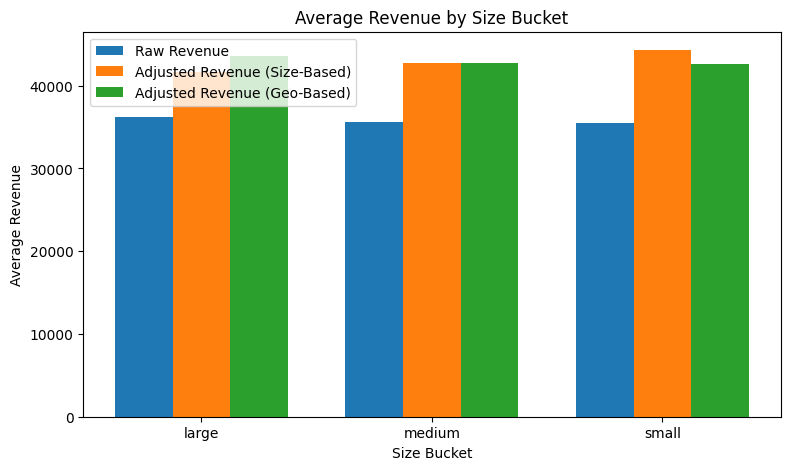

In [150]:
size_summary = (
    financial_table_matched
    .groupby("size_bucket", as_index=False)[
        ["raw_revenue", "adjusted_revenue", "adjusted_revenue_geo"]
    ]
    .mean()
)

plt.figure(figsize=(9, 5))
x = np.arange(len(size_summary))
w = 0.25

plt.bar(x - w, size_summary["raw_revenue"], width=w, label="Raw Revenue")
plt.bar(x, size_summary["adjusted_revenue"], width=w, label="Adjusted Revenue (Size-Based)")
plt.bar(x + w, size_summary["adjusted_revenue_geo"], width=w, label="Adjusted Revenue (Geo-Based)")

plt.xticks(x, size_summary["size_bucket"])
plt.xlabel("Size Bucket")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Size Bucket")
plt.legend()
plt.show()

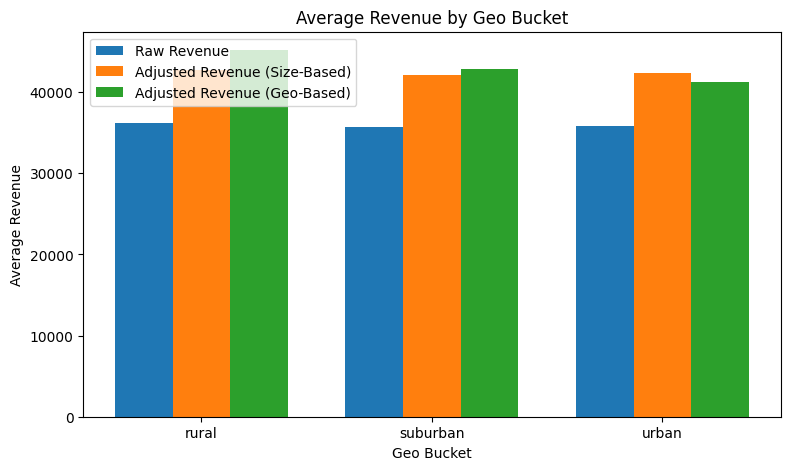

In [151]:
geo_summary = (
    financial_table_matched
    .groupby("geo_bucket", as_index=False)[
        ["raw_revenue", "adjusted_revenue", "adjusted_revenue_geo"]
    ]
    .mean()
)

plt.figure(figsize=(9, 5))
x = np.arange(len(geo_summary))
w = 0.25

plt.bar(x - w, geo_summary["raw_revenue"], width=w, label="Raw Revenue")
plt.bar(x, geo_summary["adjusted_revenue"], width=w, label="Adjusted Revenue (Size-Based)")
plt.bar(x + w, geo_summary["adjusted_revenue_geo"], width=w, label="Adjusted Revenue (Geo-Based)")

plt.xticks(x, geo_summary["geo_bucket"])
plt.xlabel("Geo Bucket")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Geo Bucket")
plt.legend()
plt.show()